In [1]:
# %% [markdown]
# # Deep Reinforcement Learning for Spatial Tripartite Matching
# This notebook formulates the spatial online matching problem (Customers, Restaurants, Drivers) 
# as an MDP and benchmarks classical operations research heuristics against advanced Deep RL 
# algorithms (REINFORCE, DQN, A2C, PPO with RNN/Transformer architectures).

# %%
import os
import copy
import math
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
from typing import List, Tuple, Dict, Optional
from tqdm.notebook import tqdm
from sklearn.neighbors import BallTree

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

# Global Style & Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

# Physics & Constraints
DISTANCE_THRESHOLD_KM = 5.0
MAX_TIME_MINUTES = 45.0
AVERAGE_SPEED_KMH = 30.0
PICKUP_BUFFER_MIN = 5.0

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on device: {DEVICE}")

Executing on device: cuda


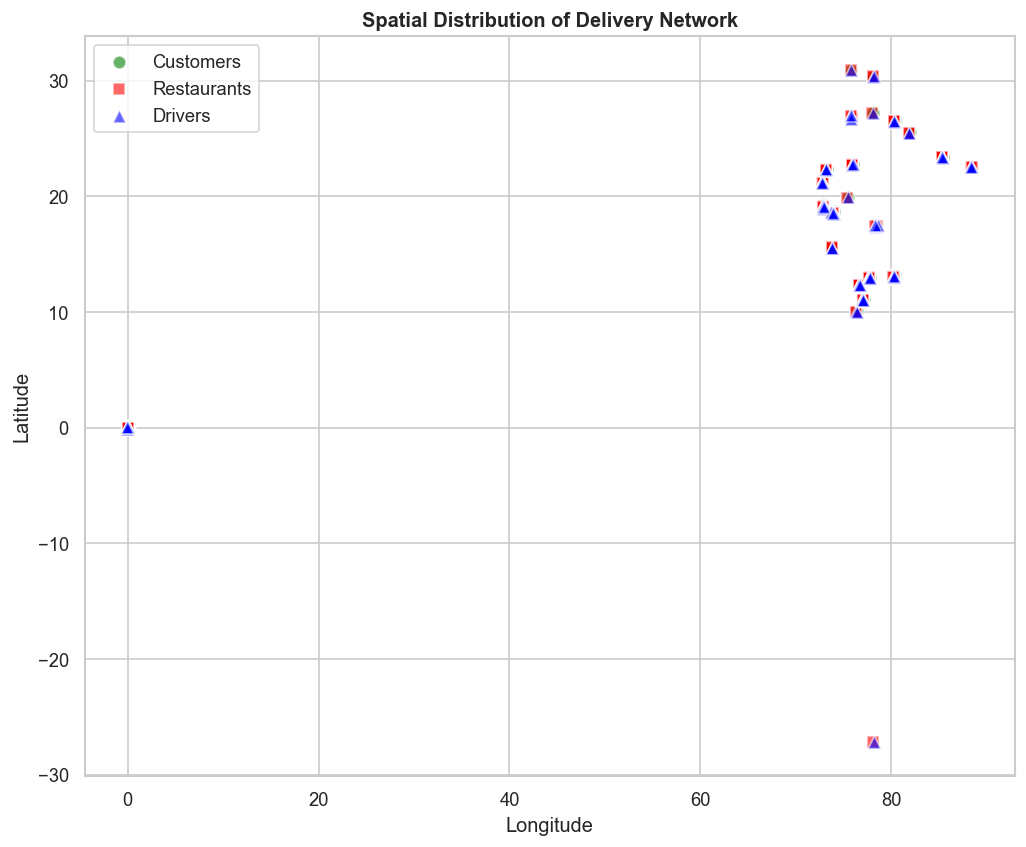

In [2]:
# %% [markdown]
# ## 1. Data Generation & Spatial Analysis
# We generate a synthetic dataset representing the spatial distribution of our tripartite graph nodes.

# %%
def haversine(lat1, lon1, lat2, lon2):
    """Calculates the great-circle distance between two points on the Earth surface."""
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    a = math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1-a)))

def get_or_create_dataset(filepath='../test/train_with_all_distances.csv', n_rows=200):
    if os.path.exists(filepath):
        return pd.read_csv(filepath).head(n_rows)
    else:
        print("Dataset not found. Generating synthetic spatial dataset...")
        data = []
        for i in range(n_rows):
            base_lat, base_lon = 40.7128, -74.0060 
            rlat = base_lat + np.random.uniform(-0.05, 0.05)
            rlon = base_lon + np.random.uniform(-0.05, 0.05)
            clat = rlat + np.random.uniform(-0.04, 0.04)
            clon = rlon + np.random.uniform(-0.04, 0.04)
            dlat = rlat + np.random.uniform(-0.04, 0.04)
            dlon = rlon + np.random.uniform(-0.04, 0.04)
            
            data.append({
                'ID': f"0x{i}",
                'Delivery_person_ID': f"DP_{i%50}", 
                'Restaurant_latitude': rlat,
                'Restaurant_longitude': rlon,
                'Delivery_location_latitude': clat,
                'Delivery_location_longitude': clon,
                'Driver_latitude': dlat,
                'Driver_longitude': dlon
            })
        return pd.DataFrame(data)

def visualize_spatial_distribution(df):
    """Plots the spatial layout of Customers, Restaurants, and Drivers."""
    plt.figure(figsize=(10, 8))
    plt.scatter(df['Delivery_location_longitude'], df['Delivery_location_latitude'], 
                c='green', label='Customers', alpha=0.6, edgecolors='w', s=60)
    plt.scatter(df['Restaurant_longitude'], df['Restaurant_latitude'], 
                c='red', label='Restaurants', marker='s', alpha=0.6, edgecolors='w', s=60)
    plt.scatter(df['Driver_longitude'], df['Driver_latitude'], 
                c='blue', label='Drivers', marker='^', alpha=0.6, edgecolors='w', s=60)
    
    plt.title("Spatial Distribution of Delivery Network", weight='bold')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

# Generate and visualize
df_spatial = get_or_create_dataset()
visualize_spatial_distribution(df_spatial)

In [3]:
# %% [markdown]
# ## 2. Spatial Matching Environment (MDP Formulation)
# Encapsulates the graph logic, tracking state transitions, valid edge generation, and computing offline optimal bounds using NetworkX bipartite matching.

# %%
class SpatialMatchingEnv:
    def __init__(self, df: pd.DataFrame, arrival_order: List[Tuple[str, str]]):
        self.df = df
        self.arrival_order = arrival_order
        self.G = self._build_graph()
        self.drivers = [n for n, d in self.G.nodes(data=True) if d.get('partition') == 'V_i']
        self.driver_to_idx = {d: i for i, d in enumerate(self.drivers)}
        self.idx_to_driver = {i: d for i, d in enumerate(self.drivers)}
        self.n_I = len(self.drivers)
        self.reset()

    def _build_graph(self):
        G = nx.Graph()
        for _, row in self.df.iterrows():
            cust_node = f"Cust_{row['ID']}"
            rest_node = f"Rest_{round(row['Restaurant_latitude'], 4)}_{round(row['Restaurant_longitude'], 4)}"
            driver_node = f"Driver_{row['Delivery_person_ID']}"
            
            G.add_node(cust_node, partition='V_l', target_rest=rest_node,
                       lat=row['Delivery_location_latitude'], lon=row['Delivery_location_longitude'])
            G.add_node(rest_node, partition='V_r', 
                       lat=row['Restaurant_latitude'], lon=row['Restaurant_longitude'])
            G.add_node(driver_node, partition='V_i', 
                       lat=row['Driver_latitude'], lon=row['Driver_longitude'])

        driver_nodes = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_i']
        rest_nodes = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_r']
        
        if not driver_nodes or not rest_nodes: return G

        # Vectorized distance thresholding using BallTree
        d_coords = np.radians([[G.nodes[n]['lat'], G.nodes[n]['lon']] for n in driver_nodes])
        r_coords = np.radians([[G.nodes[n]['lat'], G.nodes[n]['lon']] for n in rest_nodes])
        tree = BallTree(d_coords, metric='haversine')
        indices_within_radius = tree.query_radius(r_coords, r=DISTANCE_THRESHOLD_KM / 6371.0)

        for r_idx, d_indices in enumerate(indices_within_radius):
            rest_node = rest_nodes[r_idx]
            for d_idx in d_indices:
                driver_node = driver_nodes[d_idx]
                dist = haversine(G.nodes[driver_node]['lat'], G.nodes[driver_node]['lon'],
                                 G.nodes[rest_node]['lat'], G.nodes[rest_node]['lon'])
                G.add_edge(rest_node, driver_node, weight=dist)

        for cust_node in [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_l']:
            target_rest = G.nodes[cust_node]['target_rest']
            if G.has_node(target_rest):
                for driver_node in G.neighbors(target_rest):
                    dist = haversine(G.nodes[cust_node]['lat'], G.nodes[cust_node]['lon'],
                                     G.nodes[driver_node]['lat'], G.nodes[driver_node]['lon'])
                    G.add_edge(cust_node, driver_node, weight=dist)
        return G

    def reset(self):
        self.I_state = np.zeros(self.n_I, dtype=int) 
        self.driver_assignments = {i: {'L': None, 'R': None} for i in range(self.n_I)}
        self.matched_triples = []
        self.current_step = 0
        self.done = len(self.arrival_order) == 0
        return self._get_state()

    def _get_state(self):
        return {'I_state': self.I_state.copy(), 'current_step': self.current_step}

    def _is_feasible(self, c_node, d_node, r_node):
        if self.G.nodes[c_node].get('target_rest') != r_node: return False
        if not self.G.has_edge(c_node, d_node) or not self.G.has_edge(r_node, d_node): return False
        
        d_rest = self.G[r_node][d_node]['weight']
        d_c_r = haversine(self.G.nodes[r_node]['lat'], self.G.nodes[r_node]['lon'],
                          self.G.nodes[c_node]['lat'], self.G.nodes[c_node]['lon'])
        
        total_time = ((d_rest / AVERAGE_SPEED_KMH) * 60) + PICKUP_BUFFER_MIN + ((d_c_r / AVERAGE_SPEED_KMH) * 60)
        return total_time <= MAX_TIME_MINUTES

    def step(self, action_idx: Optional[int]):
        if self.done: return self._get_state(), 0.0, True
        
        node_type, node_id = self.arrival_order[self.current_step]
        reward = 0.0
        
        if action_idx is not None and action_idx < self.n_I:
            driver_node = self.idx_to_driver[action_idx]
            if node_type == 'L':  
                r_node = self.driver_assignments[action_idx]['R']
                if r_node and self._is_feasible(node_id, driver_node, r_node):
                    self.matched_triples.append((node_id, driver_node, r_node))
                    self.I_state[action_idx] = 0
                    self.driver_assignments[action_idx] = {'L': None, 'R': None}
                    reward = 1.0
                else:
                    self.I_state[action_idx] = 1
                    self.driver_assignments[action_idx]['L'] = node_id
            elif node_type == 'R': 
                c_node = self.driver_assignments[action_idx]['L']
                if c_node and self._is_feasible(c_node, driver_node, node_id):
                    self.matched_triples.append((c_node, driver_node, node_id))
                    self.I_state[action_idx] = 0
                    self.driver_assignments[action_idx] = {'L': None, 'R': None}
                    reward = 1.0
                else:
                    self.I_state[action_idx] = 2
                    self.driver_assignments[action_idx]['R'] = node_id

        self.current_step += 1
        if self.current_step >= len(self.arrival_order):
            self.done = True
        return self._get_state(), reward, self.done

    def get_eligible_drivers(self, node_type, node_id) -> List[int]:
        eligible = []
        for i, driver in self.idx_to_driver.items():
            if node_type == 'L' and self.G.has_edge(node_id, driver) and self.I_state[i] in [0, 2]:
                eligible.append(i)
            elif node_type == 'R' and self.G.has_edge(node_id, driver) and self.I_state[i] in [0, 1]:
                eligible.append(i)
        return eligible

    def compute_offline_optimal(self):
        B = nx.Graph()
        for c in [n for n, d in self.G.nodes(data=True) if d.get('partition') == 'V_l']:
            target_r = self.G.nodes[c].get('target_rest')
            if not self.G.has_node(target_r): continue
            shared_drivers = set(self.G.neighbors(c)).intersection(set(self.G.neighbors(target_r)))
            for d in shared_drivers:
                if self._is_feasible(c, d, target_r): B.add_edge(f"Order_{c}_{target_r}", d)
        # Bipartite matching provides the absolute upper bound of matching capacity
        return len(nx.bipartite.maximum_matching(B, top_nodes=[n for n in B.nodes if n.startswith("Order")])) // 2

In [4]:
# %% [markdown]
# ## 3. Operations Research Heuristics
# We define standard benchmark algorithms to compare against our learning agents.

# %%
class BaseAlgorithm:
    def run_episode(self, env):
        env.reset()
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            action = self.select_action(env, ntype, nid, eligible)
            env.step(action if action is not None and action < env.n_I else None)
        return len(env.matched_triples)

class RandomAlgorithm(BaseAlgorithm):
    def select_action(self, env, node_type, node_id, eligible):
        return random.choice(eligible) if eligible else None

class MinDistanceAlgorithm(BaseAlgorithm):
    """Greedily picks the driver physically closest to the incoming node."""
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible: return None
        return min(eligible, key=lambda idx: env.G[node_id][env.idx_to_driver[idx]]['weight'])

class MinDegreeAlgorithm(BaseAlgorithm):
    """Preserves highly connected drivers by assigning the least flexible driver first."""
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible: return None
        return min(eligible, key=lambda idx: env.G.degree(env.idx_to_driver[idx]))
    
class EpsilonRankingAlgorithm(BaseAlgorithm):
    def __init__(self, n_I: int):
        self.ranks = np.random.uniform(0, 1, n_I)
    def select_action(self, env, node_type, node_id, eligible):
        if not eligible: return None
        return min(eligible, key=lambda i: self.ranks[i])

In [10]:
# %% [markdown]
# ## 4. Deep Learning Architectures
# Implements MLP, RNNs, Self-Attention, and a Graph Neural Network (GNN) node embedding.

# %%
class UnifiedRLNetwork(nn.Module):
    def __init__(self, n_I, arch='lstm', is_q_net=False, hidden_dim=128): 
        super().__init__()
        self.n_I = n_I
        self.arch = arch
        self.is_q_net = is_q_net
        self.input_dim = 2 + n_I + (3 * n_I) + 1  
        
        # 1. Base Architectures
        if arch == 'mlp':
            self.core = nn.Sequential(
                nn.Linear(self.input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), 
                nn.Linear(hidden_dim, hidden_dim), nn.GELU()
            )
        elif arch in ['lstm', 'gru']:
            RNNClass = nn.LSTM if arch == 'lstm' else nn.GRU
            self.core = RNNClass(self.input_dim, hidden_dim, batch_first=True)
        elif arch == 'transformer':
            self.input_proj = nn.Linear(self.input_dim, hidden_dim)
            encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, dim_feedforward=hidden_dim*2, batch_first=True) 
            self.core = nn.TransformerEncoder(encoder_layer, num_layers=2) 
        elif arch == 'gnn_mock':
            # Use a fixed embedding size per driver node to avoid integer division truncation
            self.node_emb_dim = 8 
            self.node_proj = nn.Linear(3, self.node_emb_dim) # Project the 3-state one-hot vector
            # Global projection expects (number_of_drivers * node_emb_dim) + 3 global features
            self.global_proj = nn.Linear((self.n_I * self.node_emb_dim) + 3, hidden_dim)
            
        # 2. Heads
        if is_q_net:
            self.q_head = nn.Linear(hidden_dim, n_I + 1)
        else:
            self.actor = nn.Linear(hidden_dim, n_I + 1)
            self.critic = nn.Linear(hidden_dim, 1) # Note: GRPO and DPO will ignore the critic

    def forward(self, x, hidden=None):
        if self.arch == 'mlp':
            out = self.core(x)
        elif self.arch in ['lstm', 'gru']:
            out, hidden = self.core(x, hidden)
            out = out[:, -1:, :]
        elif self.arch == 'transformer':
            x = self.input_proj(x)
            out = self.core(x)
            out = out[:, -1:, :] 
        elif self.arch == 'gnn_mock':
            # Extract driver states from the flattened feature vector
            driver_states = x[:, :, 2+self.n_I : 2+self.n_I+(3*self.n_I)].view(x.size(0), x.size(1), self.n_I, 3)
            node_embs = F.gelu(self.node_proj(driver_states))
            
            # Flatten nodes back down -> shape: [batch, seq, n_I * node_emb_dim]
            graph_emb = node_embs.view(x.size(0), x.size(1), -1) 
            global_feats = torch.cat([x[:, :, :2], x[:, :, -1:]], dim=-1) # Extract Node type + Step
            
            # Combine Graph Embeddings with global properties
            out = F.gelu(self.global_proj(torch.cat([graph_emb, global_feats], dim=-1)))
            
        if self.is_q_net:
            return self.q_head(out), hidden
        return self.actor(out), self.critic(out), hidden

In [6]:
# %% [markdown]
# ## 5. RL Agents (PPO, A2C, DQN)
# Implementation of modern Policy Gradient and Value-Based methods. PPO includes Generalized Advantage Estimation (GAE).

# %%
class BaseRLAgent(BaseAlgorithm):
    def __init__(self, n_I, arch):
        self.n_I = n_I
        self.device = DEVICE
        self.arch = arch
        self.losses = []
        
    def _get_features(self, env, node_type, node_id):
        type_vec = [1, 0] if node_type == 'L' else [0, 1]
        neigh_vec = np.zeros(self.n_I)
        for d in (env.G.neighbors(node_id) if env.G.has_node(node_id) else []):
            if d in env.driver_to_idx: neigh_vec[env.driver_to_idx[d]] = 1.0
        state_vec = np.zeros(3 * self.n_I)
        for i, st in enumerate(env.I_state): state_vec[3*i + st] = 1.0
        step_vec = [env.current_step / max(1, len(env.arrival_order))]
        feat = np.concatenate([type_vec, neigh_vec, state_vec, step_vec])
        return torch.FloatTensor(feat).unsqueeze(0).unsqueeze(0).to(self.device)

    def run_episode(self, env):
        env.reset()
        hidden, seq_buffer = None, []
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(seq_buffer[-10:], dim=1) # Context window
            else:
                feat_input = feat
                
            action, hidden = self._select_eval_action(feat_input, eligible, hidden)
            env.step(action if action < self.n_I else None)
        return len(env.matched_triples)

class PPOAgent(BaseRLAgent):
    """SOTA Proximal Policy Optimization with Generalized Advantage Estimation (GAE)."""
    def __init__(self, n_I, arch='gru', clip=0.2, gamma=0.99, lam=0.95):
        super().__init__(n_I, arch)
        self.clip = clip
        self.gamma = gamma
        self.lam = lam
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=3e-4)

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        probs = torch.softmax(logits.view(-1) + mask, dim=-1)
        return torch.argmax(probs).item(), hidden

    def train_episode(self, env):
        env.reset()
        hidden, states, actions, old_log_probs, rewards, values = None, [], [], [], [], []
        seq_buffer = []

        # 1. Rollout Trajectory
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(seq_buffer[-10:], dim=1)
            else:
                feat_input = feat
            
            logits, val, hidden = self.net(feat_input, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            probs = torch.softmax(logits.view(-1) + mask, dim=-1)
            m = Categorical(probs)
            action = m.sample()
            
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            states.append((feat_input, eligible))
            actions.append(action)
            old_log_probs.append(m.log_prob(action).detach())
            rewards.append(reward)
            values.append(val.detach().view(-1))

        if not rewards: return 0

        # 2. Compute GAE and Returns
        values = torch.cat(values).cpu().numpy()
        advantages = np.zeros_like(rewards, dtype=np.float32)
        last_adv = 0
        for t in reversed(range(len(rewards))):
            next_val = values[t+1] if t + 1 < len(rewards) else 0.0
            delta = rewards[t] + self.gamma * next_val - values[t]
            advantages[t] = last_adv = delta + self.gamma * self.lam * last_adv
            
        returns = torch.tensor(advantages + values).to(self.device)
        advantages = torch.tensor(advantages).to(self.device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 3. PPO Surrogate Loss Update
        ep_loss = 0
        for _ in range(3): # Epochs
            hidden = None
            self.optimizer.zero_grad()
            total_loss = 0
            for (feat, elig), a, old_lp, adv, ret in zip(states, actions, old_log_probs, advantages, returns):
                if hidden is not None:
                    hidden = tuple(h.detach() for h in hidden) if isinstance(hidden, tuple) else hidden.detach()
                        
                logits, v, hidden = self.net(feat, hidden)
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if elig: mask[elig] = 0
                
                m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
                ratio = torch.exp(m.log_prob(a) - old_lp)
                
                surr1 = ratio * adv
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * adv
                loss = -torch.min(surr1, surr2) + 0.5 * F.mse_loss(v.view(-1), ret.view(-1)) - 0.01 * m.entropy()
                total_loss += loss
                
            if isinstance(total_loss, torch.Tensor):
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=0.5)
                self.optimizer.step()
                ep_loss = total_loss.item()
                
        self.losses.append(ep_loss)
        return sum(rewards)

class DQNAgent(BaseRLAgent):
    """Deep Q-Network with Replay Buffer and Epsilon Decay."""
    def __init__(self, n_I, arch='mlp'):
        super().__init__(n_I, arch)
        self.net = UnifiedRLNetwork(n_I, arch=arch, is_q_net=True).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)
        self.memory = deque(maxlen=2000)
        self.epsilon = 1.0

    def _select_eval_action(self, feat, eligible, hidden):
        q_vals, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        return torch.argmax(q_vals.view(-1) + mask).item(), hidden

    def train_episode(self, env):
        env.reset()
        hidden = None
        ep_reward, ep_loss = 0, 0
        
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if random.random() < self.epsilon:
                action = random.choice(eligible + [self.n_I])
                q_vals, hidden = self.net(feat, hidden) 
            else:
                q_vals, hidden = self.net(feat, hidden)
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if eligible: mask[eligible] = 0
                action = torch.argmax(q_vals.view(-1) + mask).item()
                
            _, reward, _ = env.step(action if action < self.n_I else None)
            ep_reward += reward
            self.memory.append((feat, action, reward))
            
            if len(self.memory) > 32: 
                batch = random.sample(self.memory, 32) 
                f_b = torch.cat([b[0] for b in batch], dim=0)
                a_b = torch.tensor([b[1] for b in batch]).to(self.device)
                r_b = torch.tensor([b[2] for b in batch], dtype=torch.float32).to(self.device)
                
                q_out, _ = self.net(f_b)
                q_out = q_out.squeeze(1) 
                q_acted = q_out.gather(1, a_b.unsqueeze(1)).squeeze(1)
                
                loss = F.mse_loss(q_acted, r_b) 
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                ep_loss += loss.item()
                
        self.epsilon = max(0.05, self.epsilon * 0.98)
        self.losses.append(ep_loss)
        return ep_reward
    
class A2CAgent(BaseRLAgent):
    """Advantage Actor-Critic (A2C) baseline model."""
    def __init__(self, n_I, arch='mlp', gamma=0.99):
        super().__init__(n_I, arch)
        self.gamma = gamma
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-3)

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        probs = torch.softmax(logits.view(-1) + mask, dim=-1)
        return torch.argmax(probs).item(), hidden

    def train_episode(self, env):
        env.reset()
        hidden, seq_buffer = None, []
        log_probs, values, rewards = [], [], []

        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            if self.arch == 'transformer':
                seq_buffer.append(feat)
                feat_input = torch.cat(seq_buffer[-10:], dim=1)
            else:
                feat_input = feat

            logits, val, hidden = self.net(feat_input, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            probs = torch.softmax(logits.view(-1) + mask, dim=-1)
            m = Categorical(probs)
            action = m.sample()
            
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            log_probs.append(m.log_prob(action))
            values.append(val.view(-1))
            rewards.append(reward)

        if not rewards: return 0

        # Compute discounted returns
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
            
        returns = torch.tensor(returns).to(self.device)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Compute A2C Loss
        policy_losses, value_losses = [], []
        for log_prob, value, R in zip(log_probs, values, returns):
            advantage = R - value.item()
            policy_losses.append(-log_prob * advantage)
            value_losses.append(F.smooth_l1_loss(value, torch.tensor([R]).to(self.device)))

        self.optimizer.zero_grad()
        loss = torch.stack(policy_losses).sum() + torch.stack(value_losses).sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=0.5)
        self.optimizer.step()
        
        self.losses.append(loss.item())
        return sum(rewards)
    
class GRPOAgent(BaseRLAgent):
    """
    Group Relative Policy Optimization.
    Samples a group of G trajectories, normalizes rewards within the group, 
    and updates policy without a Value Network.
    """
    def __init__(self, n_I, arch='mlp', group_size=4, clip=0.2):
        super().__init__(n_I, arch)
        self.group_size = group_size
        self.clip = clip
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.optimizer = optim.Adam(self.net.actor.parameters(), lr=3e-4) # Only optimizing Actor!

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        return torch.argmax(torch.softmax(logits.view(-1) + mask, dim=-1)).item(), hidden

    def train_episode(self, env):
        # We need to run G rollouts on the SAME arrival order to compare relative performance
        group_trajectories = []
        group_rewards = []
        
        for g in range(self.group_size):
            env.reset()
            states, actions, old_log_probs = [], [], []
            hidden, seq_buffer = None, []
            
            while not env.done:
                ntype, nid = env.arrival_order[env.current_step]
                eligible = env.get_eligible_drivers(ntype, nid)
                feat = self._get_features(env, ntype, nid)
                
                feat_input = feat if self.arch != 'transformer' else torch.cat((seq_buffer.append(feat) or seq_buffer)[-10:], dim=1)
                
                logits, _, hidden = self.net(feat_input, hidden) # No critic used
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if eligible: mask[eligible] = 0
                
                m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
                action = m.sample()
                _, _, _ = env.step(action.item() if action.item() < self.n_I else None)
                
                states.append((feat_input, eligible))
                actions.append(action)
                old_log_probs.append(m.log_prob(action).detach())
                
            group_trajectories.append((states, actions, old_log_probs))
            group_rewards.append(len(env.matched_triples))

        if len(group_rewards) < 2: return group_rewards[0] if group_rewards else 0

        # Compute Relative Advantages within the Group
        R_tensor = torch.tensor(group_rewards, dtype=torch.float32, device=self.device)
        advantages = (R_tensor - R_tensor.mean()) / (R_tensor.std() + 1e-8)

        # GRPO Policy Update
        self.optimizer.zero_grad()
        total_loss = 0
        
        for g, (states, actions, old_log_probs) in enumerate(group_trajectories):
            adv = advantages[g]
            hidden = None
            for (feat, elig), a, old_lp in zip(states, actions, old_log_probs):
                logits, _, hidden = self.net(feat, hidden)
                mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                mask[-1] = 0
                if elig: mask[elig] = 0
                
                m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
                ratio = torch.exp(m.log_prob(a) - old_lp)
                surr1 = ratio * adv
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * adv
                
                # GRPO Loss: only policy surrogate and KL penalty (entropy)
                total_loss += -torch.min(surr1, surr2) - 0.01 * m.entropy()

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.actor.parameters(), max_norm=0.5)
        self.optimizer.step()
        
        self.losses.append(total_loss.item())
        return sum(group_rewards) / self.group_size # Return average matches for this train step


class DPOAgent(BaseRLAgent):
    """
    Direct Preference Optimization (adapted for RL).
    Maintains a reference model. Collects pairs of actions, 
    preferring actions that led to a match over those that didn't.
    """
    def __init__(self, n_I, arch='mlp', beta=0.1):
        super().__init__(n_I, arch)
        self.beta = beta
        self.net = UnifiedRLNetwork(n_I, arch=arch).to(self.device)
        self.ref_net = copy.deepcopy(self.net) # Frozen reference model
        self.ref_net.eval()
        self.optimizer = optim.Adam(self.net.parameters(), lr=1e-4)
        self.update_freq = 10
        self.ep_count = 0

    def _select_eval_action(self, feat, eligible, hidden):
        logits, _, hidden = self.net(feat, hidden)
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        mask[-1] = 0
        if eligible: mask[eligible] = 0
        return torch.argmax(torch.softmax(logits.view(-1) + mask, dim=-1)).item(), hidden

    def train_episode(self, env):
        env.reset()
        hidden, ref_hidden = None, None
        transitions = []
        
        while not env.done:
            ntype, nid = env.arrival_order[env.current_step]
            eligible = env.get_eligible_drivers(ntype, nid)
            feat = self._get_features(env, ntype, nid)
            
            # Policy action
            logits, _, hidden = self.net(feat, hidden)
            mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
            mask[-1] = 0
            if eligible: mask[eligible] = 0
            
            m = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1))
            action = m.sample()
            
            # Step env
            _, reward, _ = env.step(action.item() if action.item() < self.n_I else None)
            
            transitions.append((feat, eligible, action, reward))

        # DPO Update: Construct preferences. We prefer actions that yielded immediate reward (match)
        # over actions that yielded 0. (A simplified step-wise preference mapping).
        winners = [t for t in transitions if t[3] > 0]
        losers = [t for t in transitions if t[3] == 0]
        
        if winners and losers:
            self.optimizer.zero_grad()
            dpo_loss = 0
            
            # Sample pairs
            for _ in range(min(len(winners), 16)):
                w = random.choice(winners)
                l = random.choice(losers)
                
                for t, is_winner in [(w, True), (l, False)]:
                    feat, elig, action, _ = t
                    mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
                    mask[-1] = 0
                    if elig: mask[elig] = 0
                    
                    with torch.no_grad():
                        ref_logits, _, _ = self.ref_net(feat)
                        ref_log_prob = Categorical(torch.softmax(ref_logits.view(-1) + mask, dim=-1)).log_prob(action)
                        
                    logits, _, _ = self.net(feat)
                    pi_log_prob = Categorical(torch.softmax(logits.view(-1) + mask, dim=-1)).log_prob(action)
                    
                    ratio = pi_log_prob - ref_log_prob
                    
                    if is_winner:
                        w_ratio = ratio
                    else:
                        l_ratio = ratio
                
                # Bradley-Terry DPO Loss: -log(sigmoid(beta * (log_pi(w)/log_ref(w) - log_pi(l)/log_ref(l))))
                loss = -F.logsigmoid(self.beta * (w_ratio - l_ratio))
                dpo_loss += loss
                
            dpo_loss.backward()
            self.optimizer.step()
            self.losses.append(dpo_loss.item())

        self.ep_count += 1
        if self.ep_count % self.update_freq == 0:
            self.ref_net.load_state_dict(self.net.state_dict())

        return len(env.matched_triples)

In [11]:
# %% [markdown]
# ## 6. Ablation Training Pipeline
# Generates a grid of all required models (Heuristics + [A2C, PPO, DQN] x [MLP, LSTM, GRU, Transformer]).

# %%
def generate_arrival_orders(G: nx.Graph, n_orders: int) -> List[List[Tuple[str, str]]]:
    customers = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_l']
    restaurants = [n for n, d in G.nodes(data=True) if d.get('partition') == 'V_r']
    orders = []
    for _ in range(n_orders):
        seq = [('L', c) for c in customers] + [('R', r) for r in restaurants]
        random.shuffle(seq)
        orders.append(seq)
    return orders

class AblationPipeline:
    def __init__(self, df, epochs=150, save_dir='./saved_models'):
        self.df = df
        self.epochs = epochs
        self.save_dir = save_dir
        self.base_env = SpatialMatchingEnv(self.df, arrival_order=[])
        self.offline_opt = self.base_env.compute_offline_optimal()
        self.n_I = self.base_env.n_I
        
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        print(f"Graph Nodes: {self.base_env.G.number_of_nodes()} | Offline Bound: {self.offline_opt}")
        
        self.train_orders = generate_arrival_orders(self.base_env.G, n_orders=self.epochs)
        self.test_orders = generate_arrival_orders(self.base_env.G, n_orders=30) # Increased for stability
        
        # --- ABLATION COMBINATIONS ---
        self.models = {
            'Heur-Random': RandomAlgorithm(), 
            'Heur-Greedy': MinDistanceAlgorithm(), 
            'Heur-Degree': MinDegreeAlgorithm(),
            'Heur-Epsilon': EpsilonRankingAlgorithm(self.n_I)
        }
        
        # Core Architectures
        for arch in ['mlp', 'lstm', 'transformer', 'gnn_mock']:
            # Traditional RL
            self.models[f'A2C-{arch.upper()}'] = A2CAgent(self.n_I, arch=arch)
            self.models[f'PPO-{arch.upper()}'] = PPOAgent(self.n_I, arch=arch)
            
            # Cutting Edge LLM-Alignment applied to RL
            if arch in ['mlp', 'gnn_mock']: # Limit pairs to save compute time
                self.models[f'GRPO-{arch.upper()}'] = GRPOAgent(self.n_I, arch=arch)
                self.models[f'DPO-{arch.upper()}'] = DPOAgent(self.n_I, arch=arch)

        self.results = {}
        self.training_curves = {}

    def train_all(self):
        print("\n--- Initiating Master Ablation Training ---")
        for name, agent in self.models.items():
            if hasattr(agent, 'train_episode'):
                rewards_history = []
                pbar = tqdm(self.train_orders, desc=f"Training {name}")
                for ep, order in enumerate(pbar):
                    env = SpatialMatchingEnv(self.df, order)
                    rew = agent.train_episode(env)
                    rewards_history.append(rew)
                    pbar.set_postfix({"ep": ep + 1, "reward": round(rew, 2)})
                self.training_curves[name] = rewards_history
                
                if hasattr(agent, 'net'):
                    model_path = os.path.join(self.save_dir, f"{name}_weights.pth")
                    torch.save(agent.net.state_dict(), model_path)

    def evaluate_all(self):
        print("\n--- Evaluating Models on Test Distribution ---")
        for name, agent in self.models.items():
            rewards = []
            for order in tqdm(self.test_orders, desc=f"Evaluating {name}", leave=False):
                env = SpatialMatchingEnv(self.df, order)
                rewards.append(agent.run_episode(env))
            
            avg_reward = np.mean(rewards)
            cr = (avg_reward / self.offline_opt) if self.offline_opt > 0 else 0
            self.results[name] = {'Reward': avg_reward, 'Competitive_Ratio': cr, 'Variance': np.std(rewards)}
            
        return pd.DataFrame(self.results).T

In [8]:
# %% [markdown]
# ## 7. Comprehensive Reporting & Analysis
# Generates "research-grade" plots for competitive ratios, match variances, and RL convergence curves.

# %%
def generate_comparative_report(results_df, training_curves):
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Competitive Ratio Bar Chart
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(x=results_df.index, y=results_df['Competitive_Ratio'], ax=ax1, palette="viridis")
    ax1.set_title('Competitive Ratio Comparison', weight='bold')
    ax1.set_ylabel('Ratio (Online / Offline Optimal)')
    ax1.tick_params(axis='x', rotation=30)
    for i, v in enumerate(results_df['Competitive_Ratio']):
        ax1.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

    # 2. Match Rate Variance (Error Bars)
    ax2 = fig.add_subplot(gs[0, 1])
    sns.barplot(x=results_df.index, y=results_df['Reward'], ax=ax2, palette="magma", capsize=.1)
    ax2.errorbar(x=results_df.index, y=results_df['Reward'], yerr=results_df['Variance'], fmt='none', c='black')
    ax2.set_title('Average Total Matches (with Std. Dev)', weight='bold')
    ax2.set_ylabel('Successful Deliveries')
    ax2.tick_params(axis='x', rotation=30)

    # 3. RL Training Convergence Curves
    if training_curves:
        ax3 = fig.add_subplot(gs[1, :])
        for name, curve in training_curves.items():
            # Apply moving average smoothing
            smoothed = pd.Series(curve).rolling(window=10, min_periods=1).mean()
            ax3.plot(smoothed, label=name, linewidth=2)
        ax3.set_title('Deep RL Training Convergence (10-Ep Moving Avg)', weight='bold')
        ax3.set_xlabel('Epochs')
        ax3.set_ylabel('Total Matches (Reward)')
        ax3.legend()

    plt.suptitle('Spatial Matching Algorithms: OR Heuristics vs. Advanced RL', fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n================== FINAL ANALYTICAL METRICS ==================")
    display(results_df.sort_values(by="Competitive_Ratio", ascending=False).style.background_gradient(cmap='Greens'))

Graph Nodes: 516 | Offline Bound: 96

--- Initiating Master Ablation Training ---


Training A2C-MLP:   0%|          | 0/150 [00:00<?, ?it/s]

Training PPO-MLP:   0%|          | 0/150 [00:00<?, ?it/s]

Training GRPO-MLP:   0%|          | 0/150 [00:00<?, ?it/s]

Training DPO-MLP:   0%|          | 0/150 [00:00<?, ?it/s]

...

Evaluating A2C-GNN_MOCK:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating PPO-GNN_MOCK:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating GRPO-GNN_MOCK:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating DPO-GNN_MOCK:   0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\Arush\AppData\Local\Temp\ipykernel_17776\3223970669.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Competitive_Ratio'], ax=ax1, palette="viridis")
C:\Users\Arush\AppData\Local\Temp\ipykernel_17776\3223970669.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Reward'], ax=ax2, palette="magma", capsize=.1)


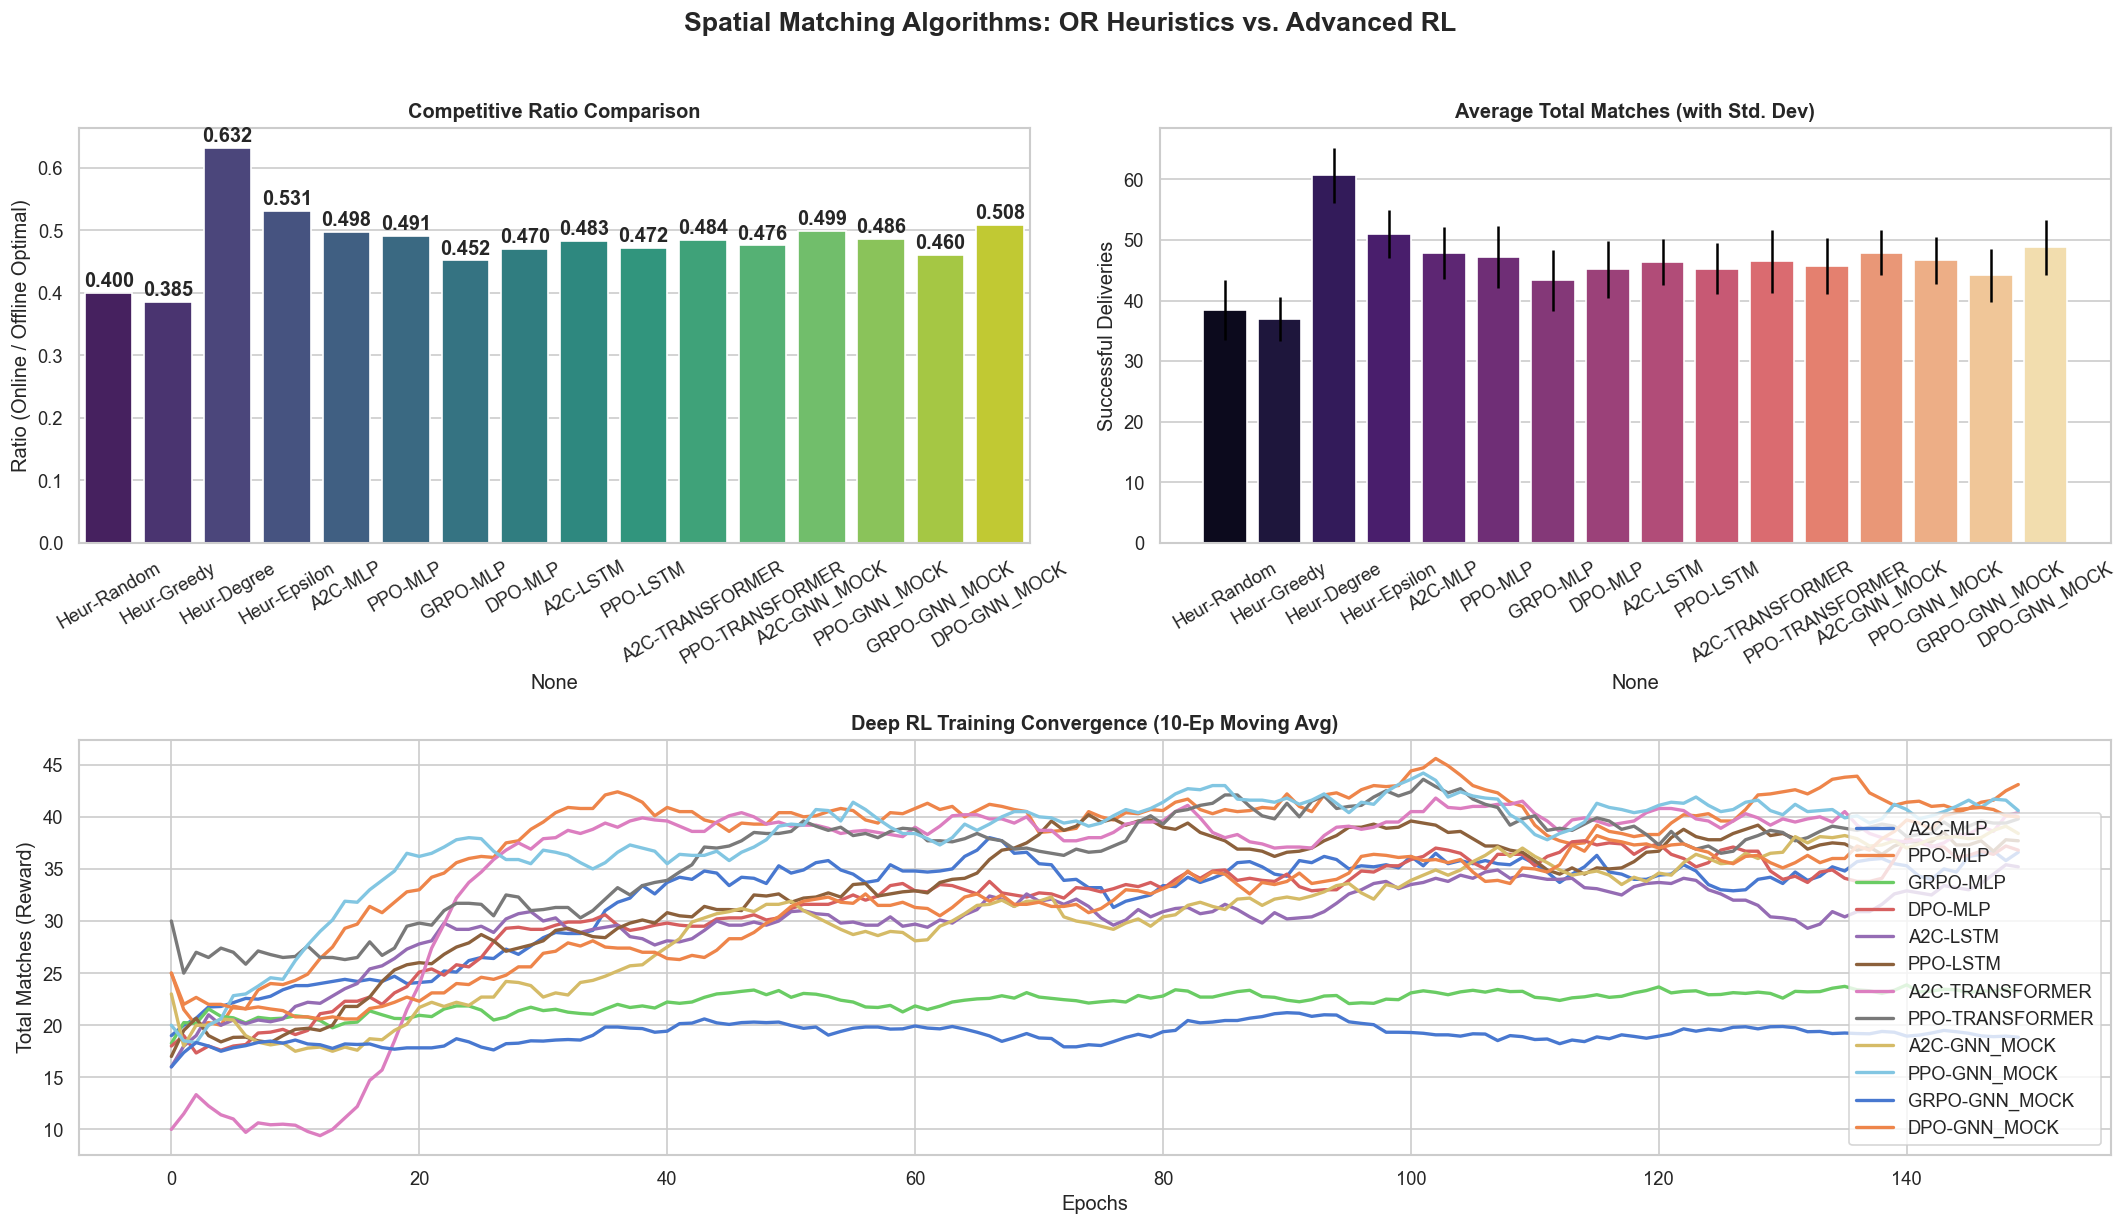


================== FINAL ANALYTICAL METRICS ==================


,Reward,Competitive_Ratio,Variance
Heur-Degree,60.700000,0.632292,4.576389
Heur-Epsilon,51.000000,0.531250,4.008325
DPO-GNN_MOCK,48.800000,0.508333,4.570923
A2C-GNN_MOCK,47.900000,0.498958,3.700000
A2C-MLP,47.800000,0.497917,4.308132
PPO-MLP,47.166667,0.491319,5.138634
PPO-GNN_MOCK,46.633333,0.485764,3.868534
A2C-TRANSFORMER,46.500000,0.484375,5.232909
A2C-LSTM,46.366667,0.482986,3.868534
PPO-TRANSFORMER,45.666667,0.475694,4.642796


In [12]:
# %% [markdown]
# ## 8. Execution
# Run the pipeline and output the final results. *Note: Processing the Transformer architecture across 150 epochs may take a few minutes depending on your hardware.*

# %%
if __name__ == "__main__":
    # Initialize pipeline with 150 epochs
    pipeline = AblationPipeline(df_spatial, epochs=150)
    
    # Train Deep RL Models
    pipeline.train_all()
    
    # Evaluate Heuristics and RL models
    results_df = pipeline.evaluate_all()
    
    # Render Dashboards
    generate_comparative_report(results_df, pipeline.training_curves)